# Telescope Data Classification - Part A

Classify telescope observations as gamma signal (`g`) or hadron background (`h`). This notebook implements the five Part A algorithms.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

Dataset shape: (18905, 11)


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


,dtype
fLength,float64
fWidth,float64
fSize,float64
fConc,float64
fConc1,float64
fAsym,float64
fM3Long,float64
fM3Trans,float64
fAlpha,float64
fDist,float64


,missing_values
fLength,0
fWidth,0
fSize,0
fConc,0
fConc1,0
fAsym,0
fM3Long,0
fM3Trans,0
fAlpha,0
fDist,0


Duplicate rows: 0


,count
class,
g,12332
h,6573


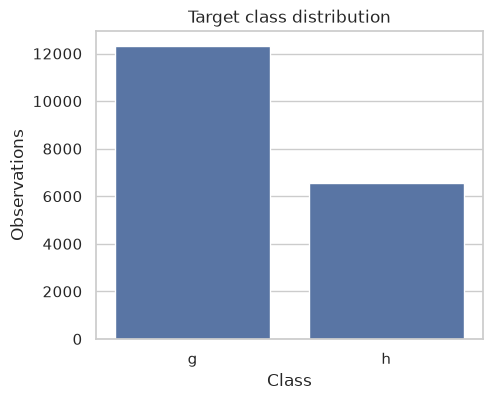

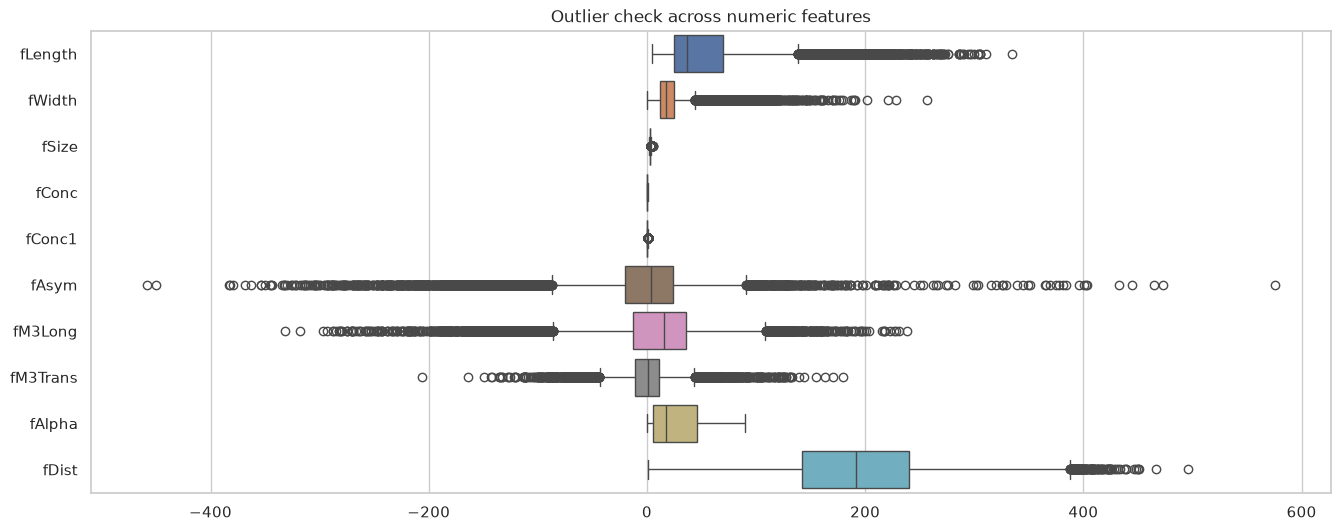

In [2]:
data_path = Path.cwd().parent / "data" / "telescope_data.csv"
if not data_path.exists():
    data_path = Path("data/telescope_data.csv")
telescope = pd.read_csv(data_path).drop(columns=["Unnamed: 0"], errors="ignore").drop_duplicates().reset_index(drop=True)
print(f"Dataset shape: {telescope.shape}")
display(telescope.head())
display(telescope.dtypes.to_frame("dtype"))
display(telescope.isna().sum().to_frame("missing_values"))
print(f"Duplicate rows: {telescope.duplicated().sum()}")
display(telescope["class"].value_counts().rename_axis("class").to_frame("count"))

plt.figure(figsize=(5, 4))
sns.countplot(data=telescope, x="class", order=["g", "h"])
plt.title("Target class distribution")
plt.xlabel("Class")
plt.ylabel("Observations")
plt.show()

plt.figure(figsize=(16, 6))
sns.boxplot(data=telescope[feature_columns] if "feature_columns" in globals() else telescope.drop(columns="class"), orient="h")
plt.title("Outlier check across numeric features")
plt.show()

The target is moderately imbalanced, so the train/test split is stratified to preserve the class proportions.

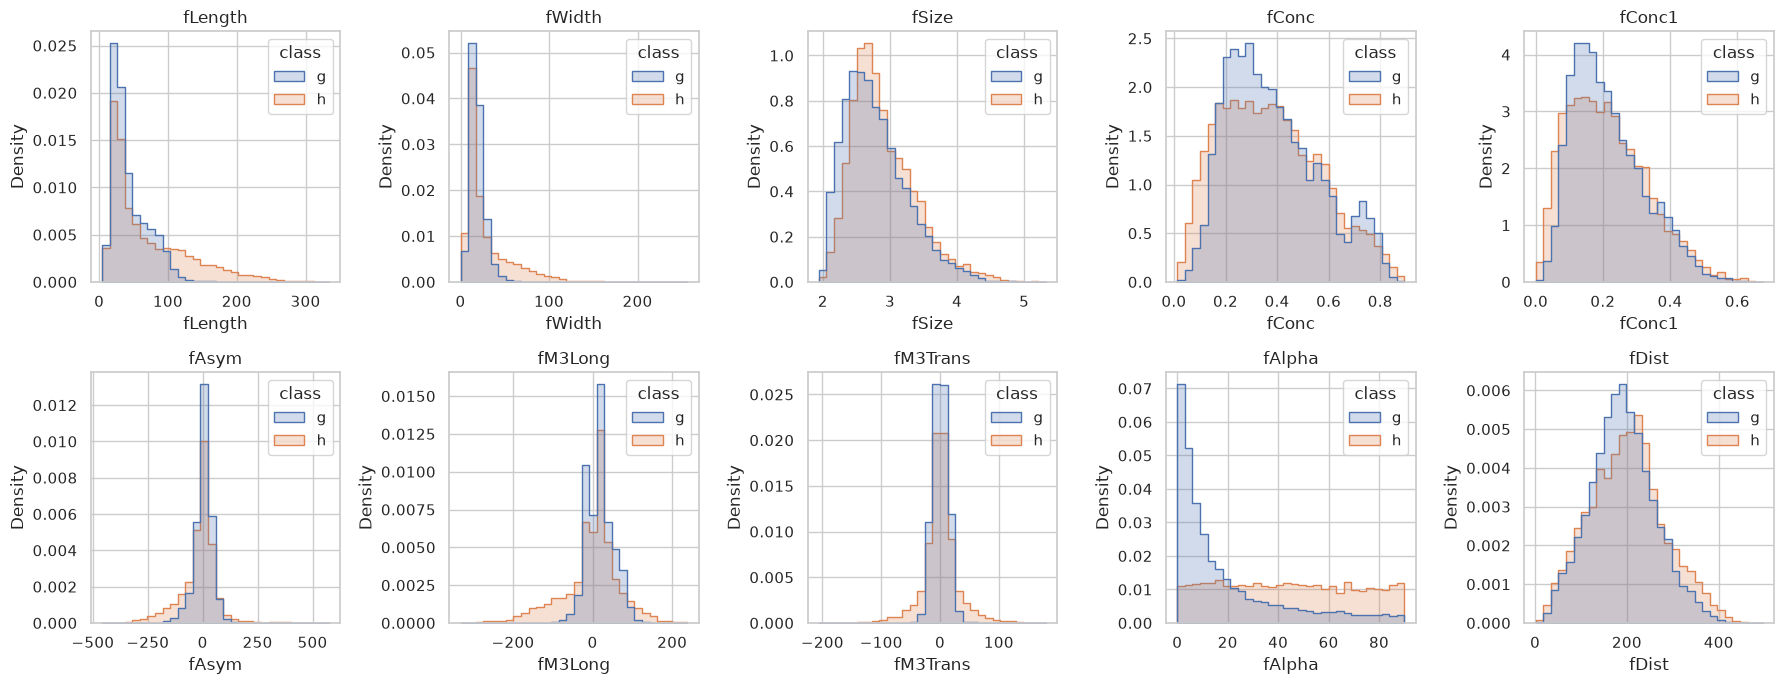

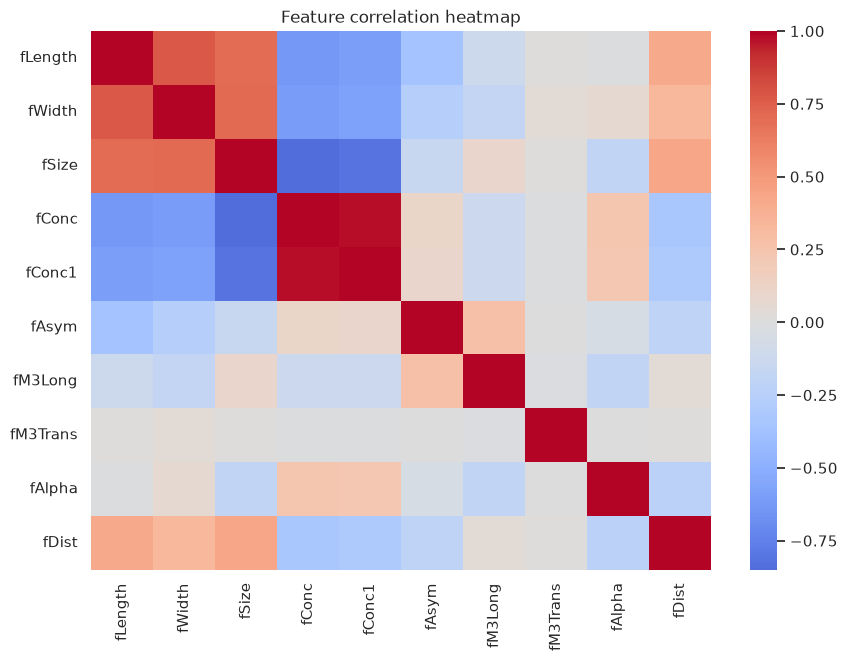

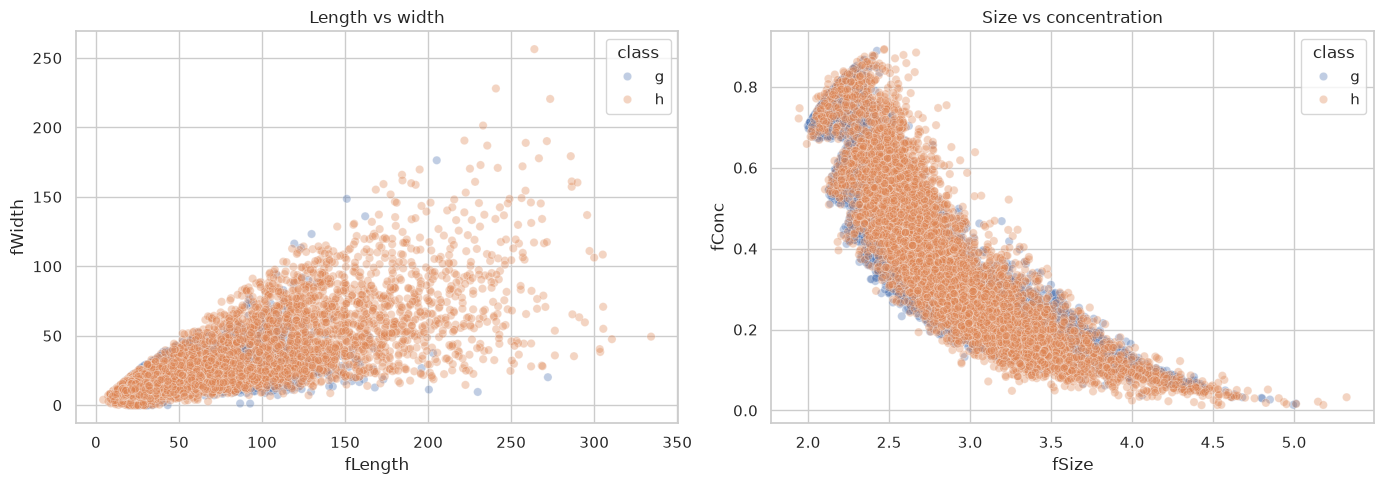

In [3]:
feature_columns = telescope.drop(columns="class").columns.tolist()
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, feature in zip(axes.ravel(), feature_columns):
    sns.histplot(data=telescope, x=feature, hue="class", bins=30, stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title(feature)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 7))
sns.heatmap(telescope[feature_columns].corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=telescope, x="fLength", y="fWidth", hue="class", alpha=0.35, ax=axes[0])
axes[0].set_title("Length vs width")
sns.scatterplot(data=telescope, x="fSize", y="fConc", hue="class", alpha=0.35, ax=axes[1])
axes[1].set_title("Size vs concentration")
plt.tight_layout()
plt.show()

The count plot shows more gamma (`g`) observations than hadron (`h`) observations, so stratification is used for a representative split.

### Distribution observation

The per-feature distributions overlap across classes, although several measurements show different concentration or spread between `g` and `h`. This supports using the complete feature set rather than a single measurement.

### Correlation observation

The heatmap highlights correlated geometric and size-related variables, indicating some redundancy. Regularised linear models can reduce the effect of this redundancy, while tree-based models can select useful thresholds.

### Scatterplot observation

The two scatterplots show substantial class overlap, so the classes are not perfectly separable in these two-dimensional views. The overlap motivates nonlinear models such as trees and RBF SVC.

In [4]:
model_data = telescope.copy()
model_data["length_width_ratio"] = model_data["fLength"] / model_data["fWidth"].replace(0, np.nan)
model_data["length_width_ratio"] = model_data["length_width_ratio"].replace([np.inf, -np.inf], np.nan)
X = model_data.drop(columns="class")
y = model_data["class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
numeric_preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
results = []
predictions = {}

def evaluate_classifier(name, estimator):
    fitted = clone(estimator)
    fitted.fit(X_train, y_train)
    y_pred = fitted.predict(X_test)
    predictions[name] = y_pred
    results.append({"Model": name, "Accuracy": accuracy_score(y_test, y_pred), "Precision (weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0), "Recall (weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0), "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0)})
    print(f"{name} classification report")
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred, labels=["g", "h"])
    display(pd.DataFrame(cm, index=["Actual g", "Actual h"], columns=["Predicted g", "Predicted h"]))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["g", "h"], yticklabels=["g", "h"])
    plt.title(f"{name} confusion matrix")
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.tight_layout()
    plt.show()
    return fitted

def show_results():
    return pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False).reset_index(drop=True)
print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")

Training rows: 15124 | Test rows: 3781


## Logistic Regression

Logistic Regression is the linear baseline. Its coefficients describe the effect of standardised feature changes on class log-odds.

Logistic Regression classification report


              precision    recall  f1-score   support

           g       0.80      0.91      0.85      2466
           h       0.77      0.58      0.66      1315

    accuracy                           0.79      3781
   macro avg       0.79      0.74      0.76      3781
weighted avg       0.79      0.79      0.78      3781



,Predicted g,Predicted h
Actual g,2238,228
Actual h,554,761


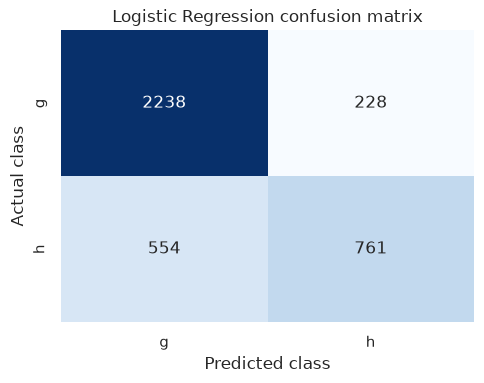

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Logistic Regression,0.793176,0.790408,0.793176,0.784956


In [5]:
logistic_model = Pipeline([("preprocessor", numeric_preprocessor), ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
logistic_fitted = evaluate_classifier("Logistic Regression", logistic_model)
show_results()

In [6]:
logistic_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_fitted.named_steps["classifier"].coef_[0],
})
logistic_coefficients["Odds ratio"] = np.exp(logistic_coefficients["Coefficient"])
logistic_coefficients["Absolute coefficient"] = logistic_coefficients["Coefficient"].abs()
logistic_coefficients = logistic_coefficients.sort_values("Absolute coefficient", ascending=False).drop(columns="Absolute coefficient")
display(logistic_coefficients)
top_logistic_features = logistic_coefficients.head(3)
print("Top Logistic Regression features by absolute coefficient:")
display(top_logistic_features)

,Feature,Coefficient,Odds ratio
0,fLength,1.193792,3.299569
8,fAlpha,1.173747,3.234089
10,length_width_ratio,-1.088775,0.336629
4,fConc1,0.579956,1.785960
6,fM3Long,-0.341287,0.710855
2,fSize,0.317133,1.373185
1,fWidth,0.148891,1.160546
9,fDist,0.052001,1.053377
3,fConc,0.031308,1.031804
7,fM3Trans,-0.014753,0.985356


Top Logistic Regression features by absolute coefficient:


,Feature,Coefficient,Odds ratio
0,fLength,1.193792,3.299569
8,fAlpha,1.173747,3.234089
10,length_width_ratio,-1.088775,0.336629


### Logistic Regression conclusion

Logistic Regression provides an interpretable linear baseline; its coefficient sign indicates whether a standardised increase raises or lowers the log-odds of class `g`, and its odds ratio is `exp(coefficient)`. Its confusion matrix shows the linear boundary misses a noticeable share of `h` observations, so nonlinear models may improve the weighted F1 score.

## K-Nearest Neighbours

KNN classifies an observation using the majority class among nearby observations. Scaling is required so high-magnitude features do not dominate the distance calculation; `k=5` provides a reproducible starting point.

K-Nearest Neighbours classification report
              precision    recall  f1-score   support

           g       0.83      0.94      0.88      2466
           h       0.86      0.64      0.73      1315

    accuracy                           0.84      3781
   macro avg       0.84      0.79      0.81      3781
weighted avg       0.84      0.84      0.83      3781



,Predicted g,Predicted h
Actual g,2327,139
Actual h,472,843


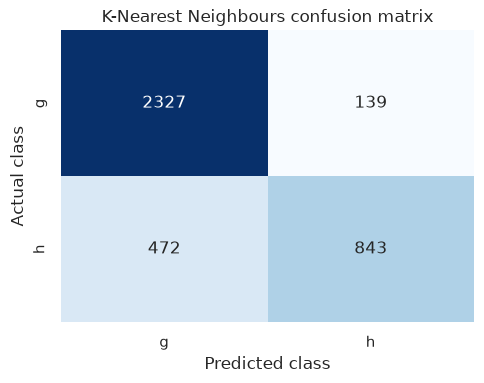

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,K-Nearest Neighbours,0.838403,0.840788,0.838403,0.831799
1,Logistic Regression,0.793176,0.790408,0.793176,0.784956


In [7]:
knn_model = Pipeline([("preprocessor", numeric_preprocessor), ("classifier", KNeighborsClassifier(n_neighbors=5, metric="minkowski"))])
knn_fitted = evaluate_classifier("K-Nearest Neighbours", knn_model)
show_results()

### K-Nearest Neighbours conclusion

KNN benefits from the scaled feature space and uses local neighbourhood structure to improve on the linear baseline. Its confusion matrix shows the trade-off between detecting `h` and preserving accuracy on the more frequent `g` class.

## Gaussian Naive Bayes

Gaussian Naive Bayes models each feature with a class-conditional Gaussian distribution and assumes conditional independence between features given the class. The assumption is strong, but the model is fast and provides a useful probabilistic baseline.

Gaussian Naive Bayes classification report
              precision    recall  f1-score   support

           g       0.83      0.62      0.71      2466
           h       0.52      0.75      0.61      1315

    accuracy                           0.67      3781
   macro avg       0.67      0.69      0.66      3781
weighted avg       0.72      0.67      0.68      3781



,Predicted g,Predicted h
Actual g,1537,929
Actual h,325,990


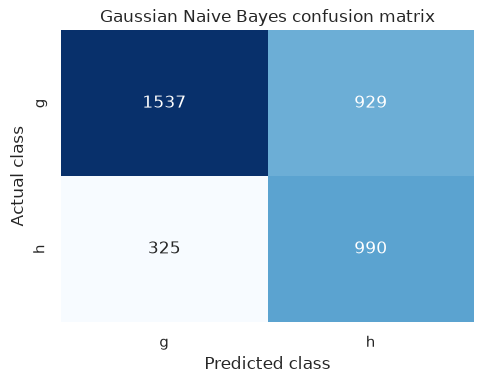

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,K-Nearest Neighbours,0.838403,0.840788,0.838403,0.831799
1,Logistic Regression,0.793176,0.790408,0.793176,0.784956
2,Gaussian Naive Bayes,0.668342,0.717793,0.668342,0.676170


In [8]:
naive_bayes_model = Pipeline([("preprocessor", numeric_preprocessor), ("classifier", GaussianNB())])
naive_bayes_fitted = evaluate_classifier("Gaussian Naive Bayes", naive_bayes_model)
show_results()

### Gaussian Naive Bayes conclusion

Gaussian Naive Bayes is computationally efficient, but its conditional-independence assumption is restrictive for correlated telescope measurements. Its confusion matrix typically shows more errors for `h`, making it a useful baseline but not the strongest model.

## Decision Tree Classifier

A decision tree learns threshold rules and does not require feature scaling. The depth is constrained to reduce overfitting and to keep the fitted tree interpretable.

Decision Tree Classifier classification report
              precision    recall  f1-score   support

           g       0.87      0.90      0.89      2466
           h       0.80      0.74      0.77      1315

    accuracy                           0.85      3781
   macro avg       0.84      0.82      0.83      3781
weighted avg       0.85      0.85      0.85      3781



,Predicted g,Predicted h
Actual g,2228,238
Actual h,339,976


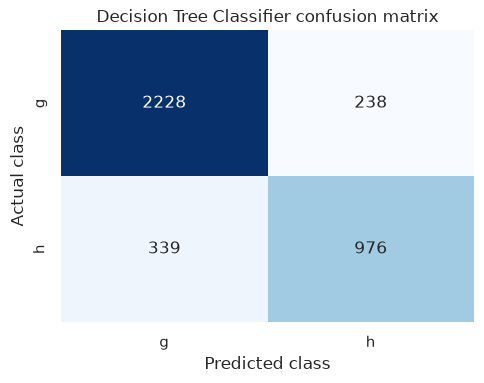

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Decision Tree Classifier,0.847395,0.845686,0.847395,0.845879
1,K-Nearest Neighbours,0.838403,0.840788,0.838403,0.831799
2,Logistic Regression,0.793176,0.790408,0.793176,0.784956
3,Gaussian Naive Bayes,0.668342,0.717793,0.668342,0.676170


In [9]:
tree_model = Pipeline([("preprocessor", SimpleImputer(strategy="median")), ("classifier", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE, class_weight="balanced"))])
tree_fitted = evaluate_classifier("Decision Tree Classifier", tree_model)
show_results()

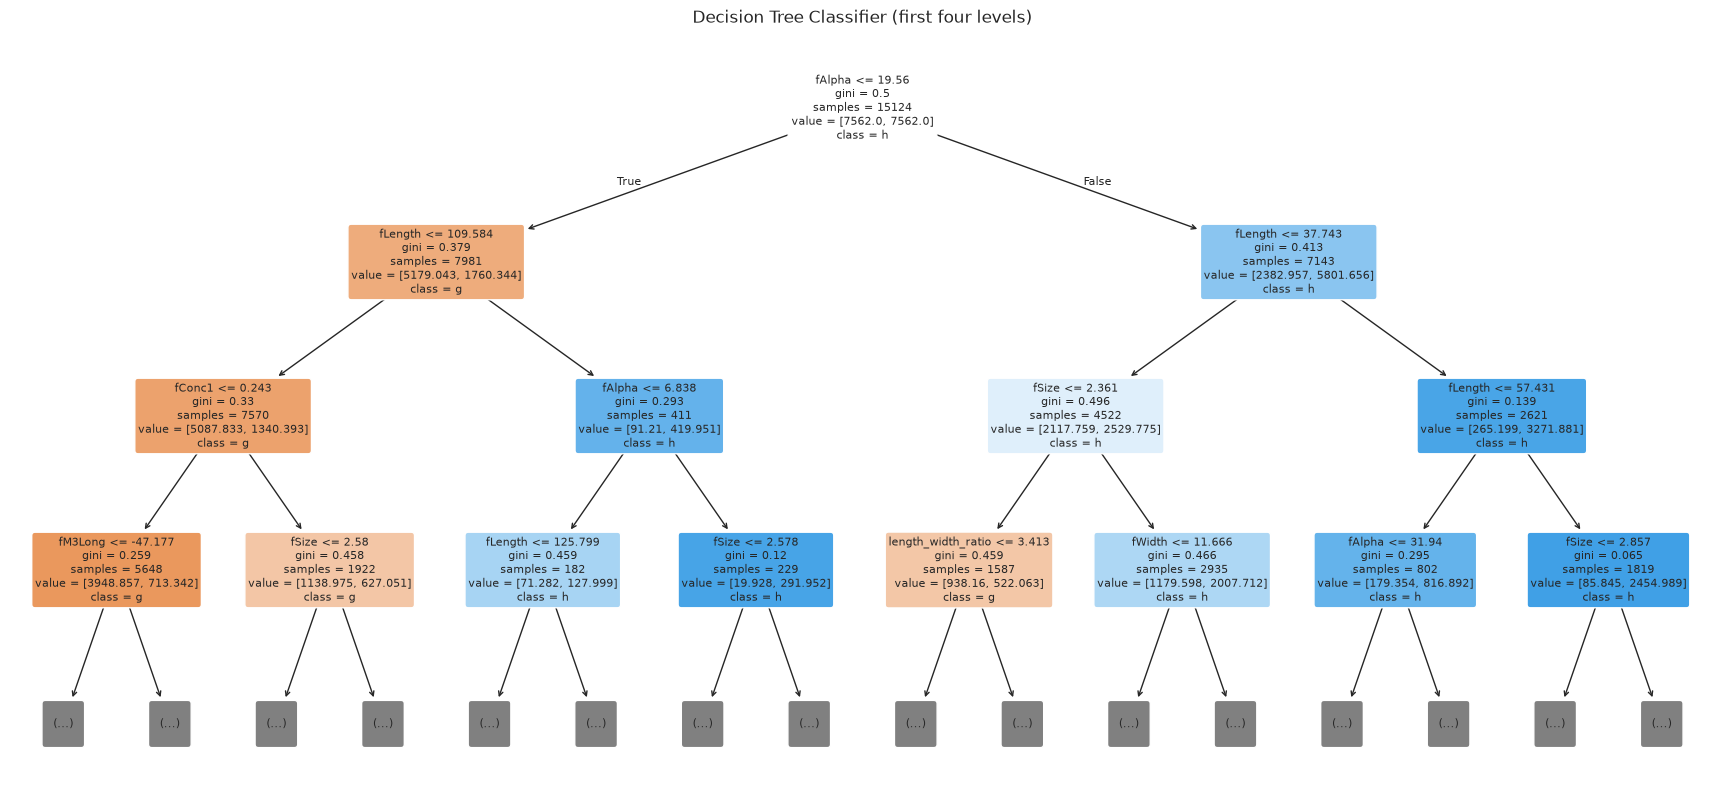

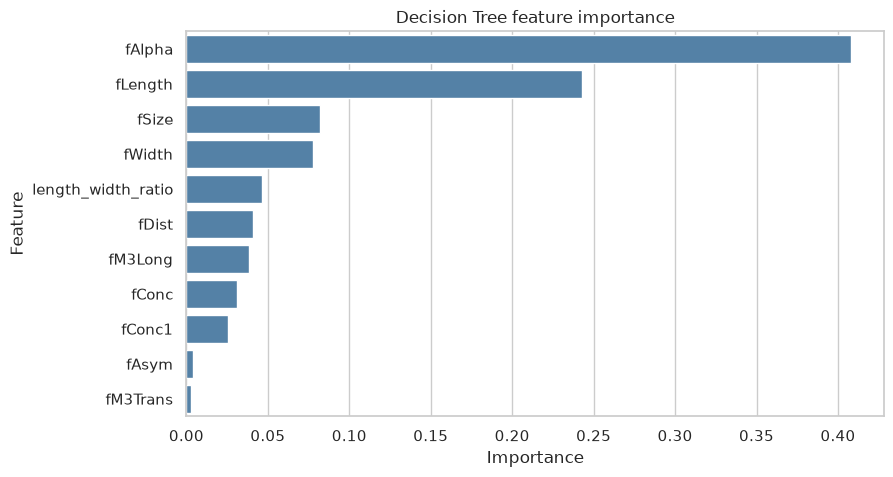

In [10]:
tree_classifier = tree_fitted.named_steps["classifier"]
plt.figure(figsize=(22, 10))
plot_tree(tree_classifier, feature_names=X.columns, class_names=["g", "h"], max_depth=3, filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree Classifier (first four levels)")
plt.show()
tree_importance = pd.Series(tree_classifier.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=tree_importance.values, y=tree_importance.index, color="steelblue")
plt.title("Decision Tree feature importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Decision Tree conclusion

The depth-limited Decision Tree captures nonlinear threshold interactions without requiring scaling. Its balanced class weighting helps reduce missed `h` observations, while the depth limit and feature-importance plot keep the model interpretable.

## Support Vector Machine (SVC)

SVC finds a separating boundary with maximum margin. The RBF kernel can model nonlinear boundaries; standardisation is part of the pipeline so the regularisation parameter `C` has a consistent meaning across features.

Support Vector Machine (SVC) classification report
              precision    recall  f1-score   support

           g       0.86      0.96      0.91      2466
           h       0.90      0.70      0.79      1315

    accuracy                           0.87      3781
   macro avg       0.88      0.83      0.85      3781
weighted avg       0.87      0.87      0.87      3781



,Predicted g,Predicted h
Actual g,2367,99
Actual h,393,922


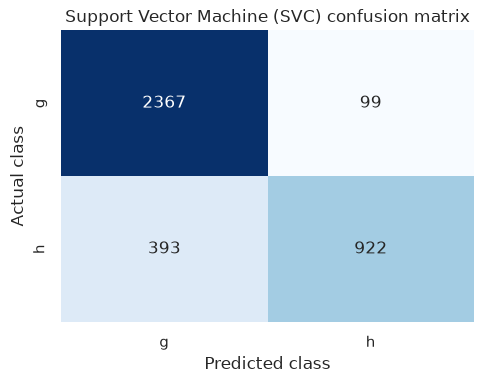

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Support Vector Machine (SVC),0.869876,0.873408,0.869876,0.865347
1,Decision Tree Classifier,0.847395,0.845686,0.847395,0.845879
2,K-Nearest Neighbours,0.838403,0.840788,0.838403,0.831799
3,Logistic Regression,0.793176,0.790408,0.793176,0.784956
4,Gaussian Naive Bayes,0.668342,0.717793,0.668342,0.676170


Best Part A model by weighted F1: Support Vector Machine (SVC)


In [11]:
svc_model = Pipeline([("preprocessor", numeric_preprocessor), ("classifier", SVC(C=1.0, kernel="rbf", random_state=RANDOM_STATE))])
svc_fitted = evaluate_classifier("Support Vector Machine (SVC)", svc_model)
comparison = show_results()
display(comparison)
best_model = comparison.iloc[0]["Model"]
print(f"Best Part A model by weighted F1: {best_model}")

### Support Vector Machine conclusion

The scaled RBF SVC can form a nonlinear margin in the combined feature space and is expected to be among the strongest Part A models. Its annotated confusion matrix and final weighted F1 score provide the comparison against the four earlier classifiers.